In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import pygam as gm
import copy as cp

In [3]:
dirdatain = './data/GG/'

species = {} # dictionary with the IDs of the species (as they change across networks)

mydf = pd.read_csv(dirdatain+'bale_pollen.csv')
mydf = mydf.fillna(0)
mydf = mydf.rename(columns={'kaBP':'age'})
mydf['age'] = -mydf['age']
mydf = mydf.sort_values(by=['age'])

In [8]:
myspecies = 'Alchemilla,Chenopodiaceae,Artemisia,Cichoroideae,Asteroideae,Carduus,Asteraceae,Vernonia,Polygonum,Tribulus,Galium,Brassicaceae,Caryophylaceae,Swertia,Senecio,Erica,Hypericum,Anthospermum,Cerastium,Apiaceae,Podocarpus,Euclea,Hagenia,Juniperus,Myrsine,Rapanea,Rosa,Schefflera,Brucea,Sapotaceae,Iridaceae,Anthyllis,Maytenus,Buxus,Psydrax,Celastraceae,Celtis,Dodonaea,Ekebergia,Ephedra,Clematis,Myrica,Hypoestes,Ziziphus,Acanthus,Allophylus,Acacia,Combretum,Commiphora,Cussonia,Dobera,Lannea,Macaranga,Olea,Jasminum,Rhus,Securinega,Teclea,Zanthoxylum,Cassia,Capparidaceae,Acalypha,Euphorbia,Euphorbiacea,Phyllantus,Tamarindus,Alchornea,Aloe,Asphodellus,Leguminosae,Rubiaceae,Blepharis,Justicia,Heliotropium,Kohautia,Indigofera,Lamiaceae,Cerealia,Plantago,Planceolata,Poaceae,Rumex,Solanum,Urticaceae,Ricinus,Saussurea'.replace(' ','_').split(',')

mydf_GG_original = pd.read_csv(dirdatain + 'bale_pollen.csv')

mydf_GG_original['kaBP'] = - mydf_GG_original['kaBP']
mydf_GG_original = mydf_GG_original.fillna(0)
mydf_GG_original = mydf_GG_original.sort_values(by=['kaBP'])

all_species = list(mydf_GG_original.columns)
metrics_list = ['accrate', 'volume', 'Lycopodium', 'Lyc.conc']

mydf_GG_original['kaBP'] = mydf_GG_original['kaBP'] * 1000  # Convert from ka to years
mydf_GG_original.rename(columns={'kaBP': 'age'}, inplace=True)


multipliers = mydf_GG_original['Lyc.conc'] * mydf_GG_original['accrate'] / (mydf_GG_original['volume'] * mydf_GG_original['Lycopodium'])

mydf_pollen = mydf_GG_original[['age'] + myspecies]
mydf_pollen = mydf_pollen.set_index('age')

mydf_pollen

,Alchemilla,Chenopodiaceae,Artemisia,Cichoroideae,Asteroideae,Carduus,Asteraceae,Vernonia,Polygonum,Tribulus,...,Lamiaceae,Cerealia,Plantago,Planceolata,Poaceae,Rumex,Solanum,Urticaceae,Ricinus,Saussurea
age,,,,,,,,,,,,,,,,,,,,,
-13675.0,0,92,21,6,23,0,14,0,0,0,...,0,0,0,0,349,0,0,0,0,0
-13546.0,3,108,17,0,0,0,16,0,0,0,...,5,0,0,0,411,0,0,0,0,0
-13489.0,4,125,5,5,22,0,33,0,0,0,...,2,0,0,0,319,0,0,0,0,1
-13459.0,4,97,0,6,20,0,35,0,0,0,...,4,0,0,0,410,0,0,0,0,1
-13442.0,1,98,12,1,14,0,13,0,0,0,...,1,0,0,0,413,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49.0,10,17,2,3,27,28,5,1,10,4,...,3,10,168,22,16,9,0,12,2,0
53.0,6,11,4,0,7,11,4,1,12,2,...,2,17,223,15,17,8,1,8,2,1
57.0,11,19,3,3,11,25,2,1,13,4,...,0,20,224,12,15,12,1,6,1,0


In [7]:
for spec in myspecies[:]: # ITERATE OVER A COPY
    if mydf_pollen[spec].sum() == 0:
        print('Species %s has all zeros!' %(spec))
        myspecies.remove(spec)

mydf = mydf_pollen[myspecies]

n = 300
fit_type = f'fit_{n}_0.01'
species = {}
vx = gm.utils.make_2d(mydf.index, verbose=False).astype('float')
for spec in myspecies:
    print('\tIterating on species %s ...' %(spec))
    vy = mydf[spec]

    mygam = gm.GAM(terms='auto', n_splines=n+1, lam=0.01).fit(vx, vy)
    # mygam = gm.GAM(terms='auto').gridsearch(vx, vy)

    species[spec] = {}
    species[spec]['prev_x'] = mydf.index.to_numpy()
    species[spec]['prev_y'] = mydf[spec].to_numpy()

    XX = mygam.generate_X_grid(term=0, n=n)
    YY = mygam.predict(XX)
    species[spec]['x'] = cp.copy(XX)[:,0]
    species[spec]['y'] = cp.copy(YY)

species_df = pd.DataFrame(species)
species_df.to_pickle('GAM_species/GG/species_%s.pkl' %(fit_type))

species_index = {}
for i, spec in enumerate(myspecies):
    species_index[spec] = i
pd.to_pickle(species_index, f'./GAM_species/GG/species_index.pkl')


Species Cerastium has all zeros!
Species Sapotaceae has all zeros!
Species Ziziphus has all zeros!
	Iterating on species Alchemilla ...
	Iterating on species Chenopodiaceae ...
	Iterating on species Artemisia ...
	Iterating on species Cichoroideae ...
	Iterating on species Asteroideae ...
	Iterating on species Carduus ...
	Iterating on species Asteraceae ...
	Iterating on species Vernonia ...
	Iterating on species Polygonum ...
	Iterating on species Tribulus ...
	Iterating on species Galium ...
	Iterating on species Brassicaceae ...
	Iterating on species Caryophylaceae ...
	Iterating on species Swertia ...
	Iterating on species Senecio ...
	Iterating on species Erica ...
	Iterating on species Hypericum ...
	Iterating on species Anthospermum ...
	Iterating on species Apiaceae ...
	Iterating on species Podocarpus ...
	Iterating on species Euclea ...
	Iterating on species Hagenia ...
	Iterating on species Juniperus ...
	Iterating on species Myrsine ...
	Iterating on species Rapanea ...
	I

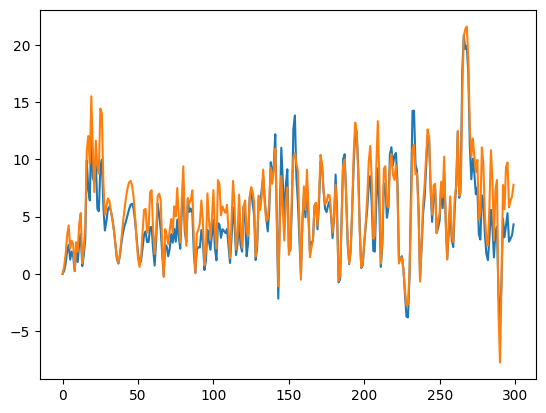

In [43]:
plt.plot(pd.read_pickle('GAM_species/GG(percentages)/species_fit_300_0.01.pkl')[species_df.columns[0]]['y']*3.5)
plt.plot(species_df[species_df.columns[0]]['y'])

In [26]:
# GAM over multipliers
n_splines = n
fit_type = 'fit_%d_0.01' %(n_splines)
vx = gm.utils.make_2d(multipliers.index, verbose=False).astype('float')
vy = multipliers.values

gam_multipliers = gm.GAM(terms='auto', n_splines=n_splines, lam=0.01).fit(vx, vy)

XX = gam_multipliers.generate_X_grid(term=0, n=n_splines)
YY = gam_multipliers.predict(XX)

gam_multipliers_df = pd.DataFrame({
    'cal BP': XX[:, 0],
    'multipliers': YY
})

gam_multipliers_df.to_pickle('./GAM_species/GG/gam_multipliers_%s.pkl' %(fit_type))